# Volterra signature validation

## Overview

| Section | What is validated |
|---|---|
| **1** | FSSK rough approximation vs predictor-corrector reference (R-sweep) |
| **2** | `vsig_fft` (orders 0-2) + predictor-corrector convergence |
| **3** | `vsig_fft` via `FSSKConvolutionKernel` vs direct SSS (adapter correctness) |
| **4** | XLA FLOP-count scaling — FFT vs quadratic (`vsig`) |

Paths are always **3-dimensional unit-speed** (total variation ≈ T, A = I_3).

In [3]:
OUTPUT_DIR = "validation_outputs"


## 1. FSSK rough approximation vs predictor-corrector reference

Sweeps the FSSK state dimension R for each β.  The predictor-corrector with high
dyadic refinement serves as the reference.  A vsig (order=2) baseline error is
also recorded.


In [5]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
# NOTE: fractional_fssk only supports beta ∈ (0.5, 1) — other values are skipped
betas_fssk      = [0.6, 0.9]
R_values        = [2, 3, 4, 6, 8, 10]
trunc_fssk      = 6
batch_fssk      = 4
steps_fssk      = 32
T_fssk          = 1.0
pc_dyadic_fssk  = 9
coef_quad_fssk  = 64
seed_fssk       = 42
dim_fssk        = 3

In [ ]:
import subprocess, sys
from pathlib import Path

script = Path("validation/sweep_fssk_approx.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--betas",           *[str(b) for b in betas_fssk],
     "--R-values",        *[str(r) for r in R_values],
     "--trunc",           str(trunc_fssk),
     "--batch",           str(batch_fssk),
     "--steps",           str(steps_fssk),
     "--T",               str(T_fssk),
     "--pc-dyadic-order", str(pc_dyadic_fssk),
     "--coef-quad-order", str(coef_quad_fssk),
     "--seed",            str(seed_fssk),
     "--dim",             str(dim_fssk),
     "--output-dir",      str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"sweep_fssk_approx.py failed (exit {result.returncode})")


In [ ]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_fssk_approx.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--output-dir", str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_fssk_approx.py failed (exit {result.returncode})")


In [ ]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path("validation") / OUTPUT_DIR

display(pd.read_csv(out / "fssk_approx_vsig.csv").pivot(
    index="level", columns="beta", values="max_abs_entry"))
display(pd.read_csv(out / "fssk_approx_fssk.csv")
        .query("level > 0")
        .groupby(["beta", "R"])["max_abs_entry"].max()
        .reset_index()
        .pivot(index="R", columns="beta", values="max_abs_entry"))

for beta in betas_fssk:
    beta_tag = f"b{beta:.2f}".replace(".", "p")
    for suffix in ["", "_aggregate"]:
        img = out / f"fssk_approx_{beta_tag}{suffix}.png"
        if img.exists():
            display(Image(filename=str(img)))


## 2. `vsig_fft` vs predictor-corrector convergence

Compares vsig_fft (orders 0, 1, 2) and the fractional PC scheme against a
high-accuracy vsig_fft reference as either the grid step count or the dyadic
refinement order increases.

Set `convergence_mode = "steps"` to sweep step counts (loglog in h), or
`"dyadic"` to sweep dyadic refinement at fixed step count (semilogy in order).


In [10]:
REGIME = "3d"   # "draft" | "paper"

_REGIMES = {
    "2d": dict(
        convergence_mode = "dyadic",
        betas_vsig       = [0.1, 0.6],
        trunc_vsig       = 6,
        batch_vsig       = 6,
        T_vsig           = 1.0,
        seed_vsig        = 7,
        dim_vsig         = 2,
        vsig_orders      = [0, 1, 2],
        n_timing_repeats = 3,
        # "steps" mode
        steps_list       = [8, 16, 32, 64, 128],
        ref_steps_factor = 4,
        # "dyadic" mode
        fixed_steps      = 2 ** 6,
        vsig_dyadic_max  = 4,
        pc_dyadic_max    = 8,
        ref_dyadic_extra = 1,
    ),
    "3d": dict(
        convergence_mode = "dyadic",
        betas_vsig       = [0.1, 0.6],
        trunc_vsig       = 6,
        batch_vsig       = 16,
        T_vsig           = 1.0,
        seed_vsig        = 7,
        dim_vsig         = 3,
        vsig_orders      = [0, 1, 2],
        n_timing_repeats = 3,
        # "steps" mode
        steps_list       = [8, 16, 32, 64, 128],
        ref_steps_factor = 4,
        # "dyadic" mode
        fixed_steps      = 2 ** 5,
        vsig_dyadic_max  = 4,
        pc_dyadic_max    = 10,
        ref_dyadic_extra = 1,
    ),
}

_cfg = _REGIMES[REGIME]
convergence_mode  = _cfg["convergence_mode"]
betas_vsig        = _cfg["betas_vsig"]
trunc_vsig        = _cfg["trunc_vsig"]
batch_vsig        = _cfg["batch_vsig"]
T_vsig            = _cfg["T_vsig"]
seed_vsig         = _cfg["seed_vsig"]
dim_vsig          = _cfg["dim_vsig"]
vsig_orders       = _cfg["vsig_orders"]
n_timing_repeats  = _cfg["n_timing_repeats"]
steps_list        = _cfg["steps_list"]
ref_steps_factor  = _cfg["ref_steps_factor"]
fixed_steps       = _cfg["fixed_steps"]
vsig_dyadic_max   = _cfg["vsig_dyadic_max"]
pc_dyadic_max     = _cfg["pc_dyadic_max"]
ref_dyadic_extra  = _cfg["ref_dyadic_extra"]


In [11]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_vsig_convergence.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--mode",       convergence_mode,
     "--output-dir", str(Path("validation") / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_vsig_convergence.py failed (exit {result.returncode})")


Loaded: validation/validation_outputs/vsig_conv_dyadic.pkl  (364 terminal rows)
  convergence_mode = dyadic
  betas = [0.1, 0.6]

β = 0.1
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_convergence.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_convergence.png
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_tradeoff.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p10_tradeoff.png

β = 0.6
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_convergence.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_convergence.png
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_tradeoff.pdf
  Saved: validation/validation_outputs/vsig_conv_dyadic_b0p60_tradeoff.png

Saved: validation/validation_outputs/vsig_conv_dyadic_rates.csv

── Convergence rates ─────────────────────────────────────────────
 beta method  order  conv_rate
  0.1   vsig    0.0   0.080380
  0.1   vsig    1.0   0.835814
  0.1   vsig   

,beta,method,order,conv_rate
0,0.1,vsig,0.0,0.080380
1,0.1,vsig,1.0,0.835814
2,0.1,vsig,2.0,1.125159
3,0.1,pc,NaN,1.172553
4,0.6,vsig,0.0,0.551803
5,0.6,vsig,1.0,1.471319
6,0.6,vsig,2.0,1.182019
7,0.6,pc,NaN,1.539157


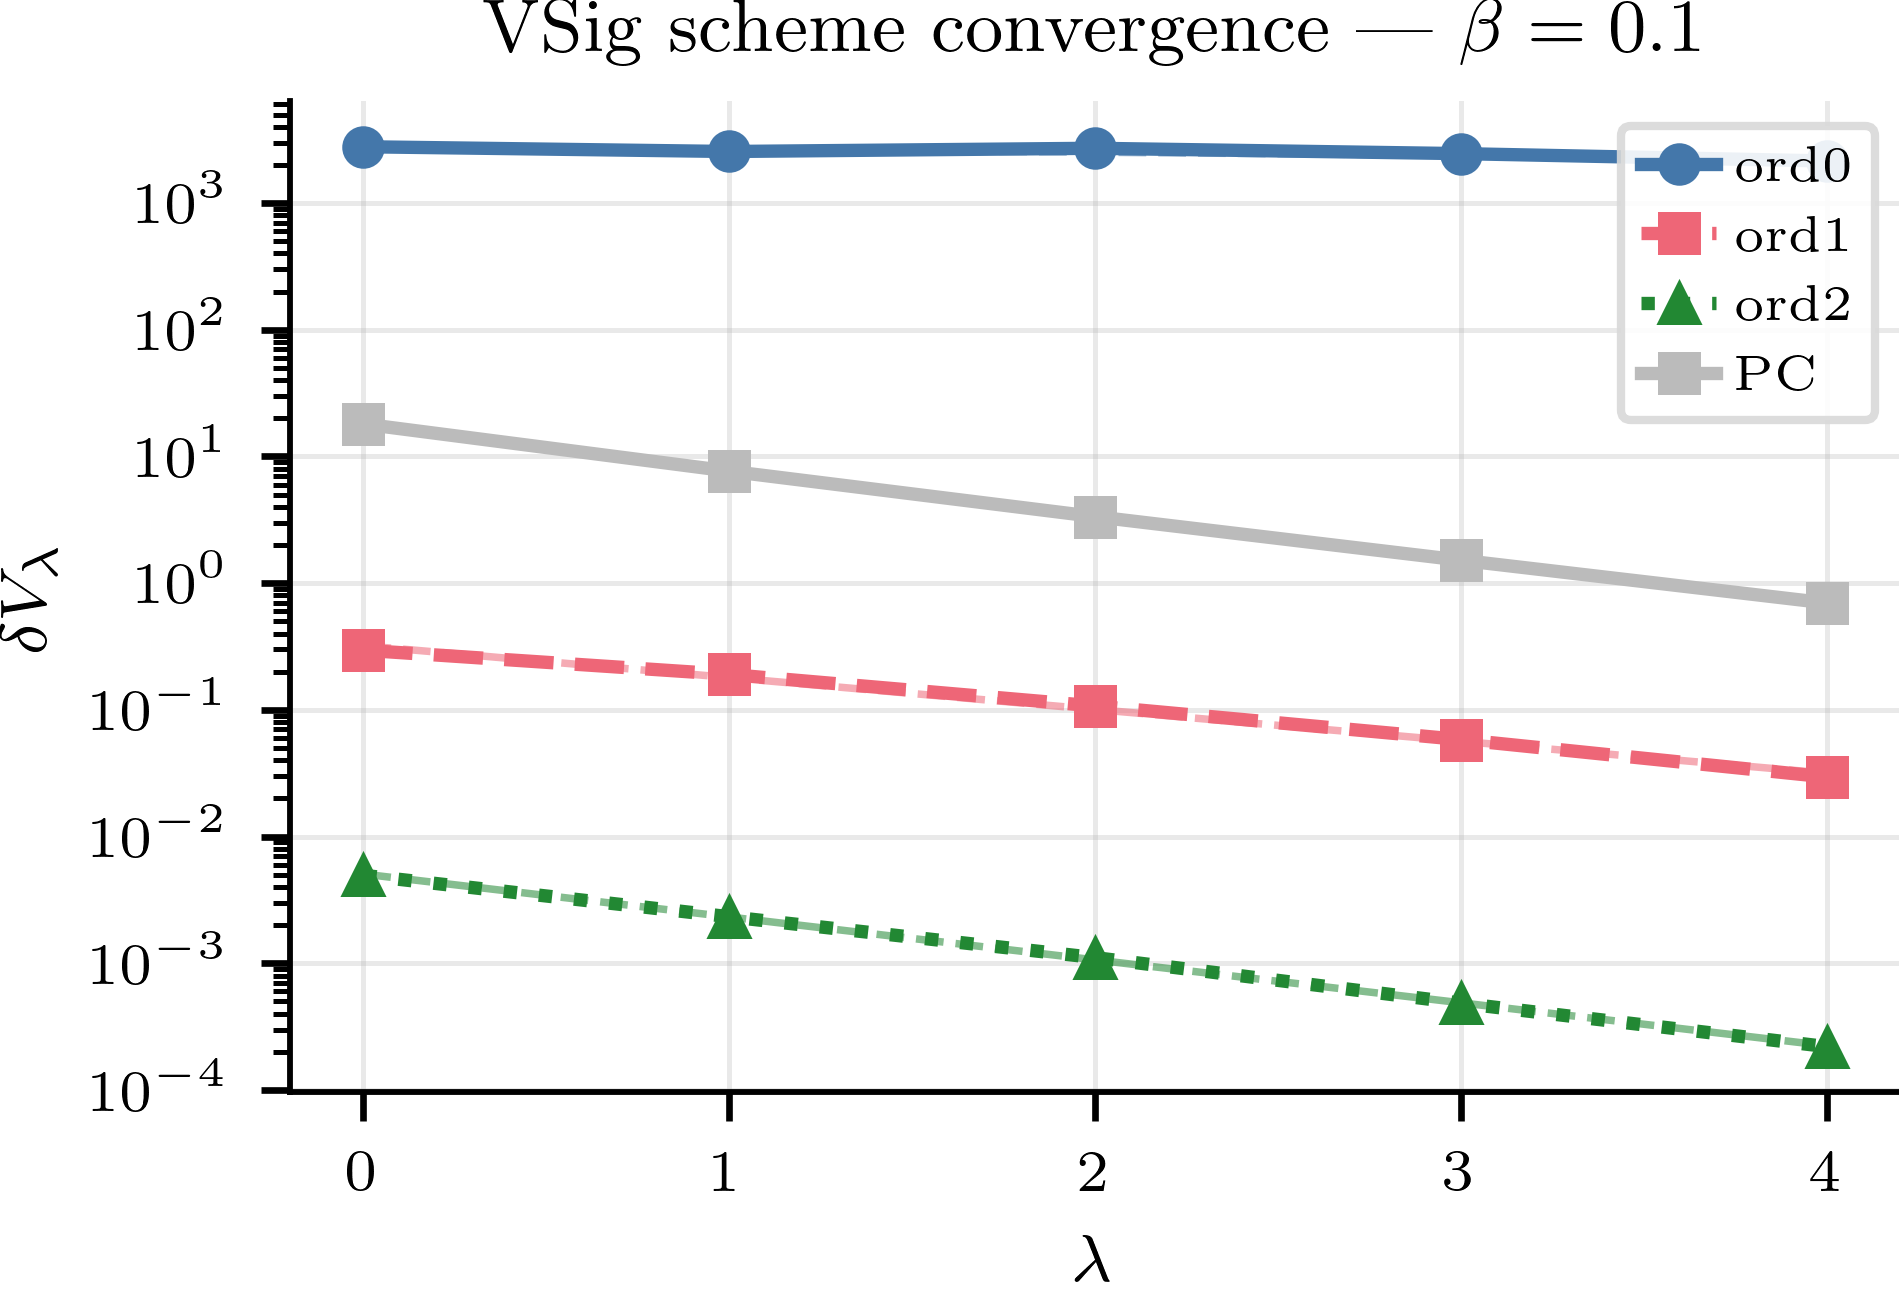

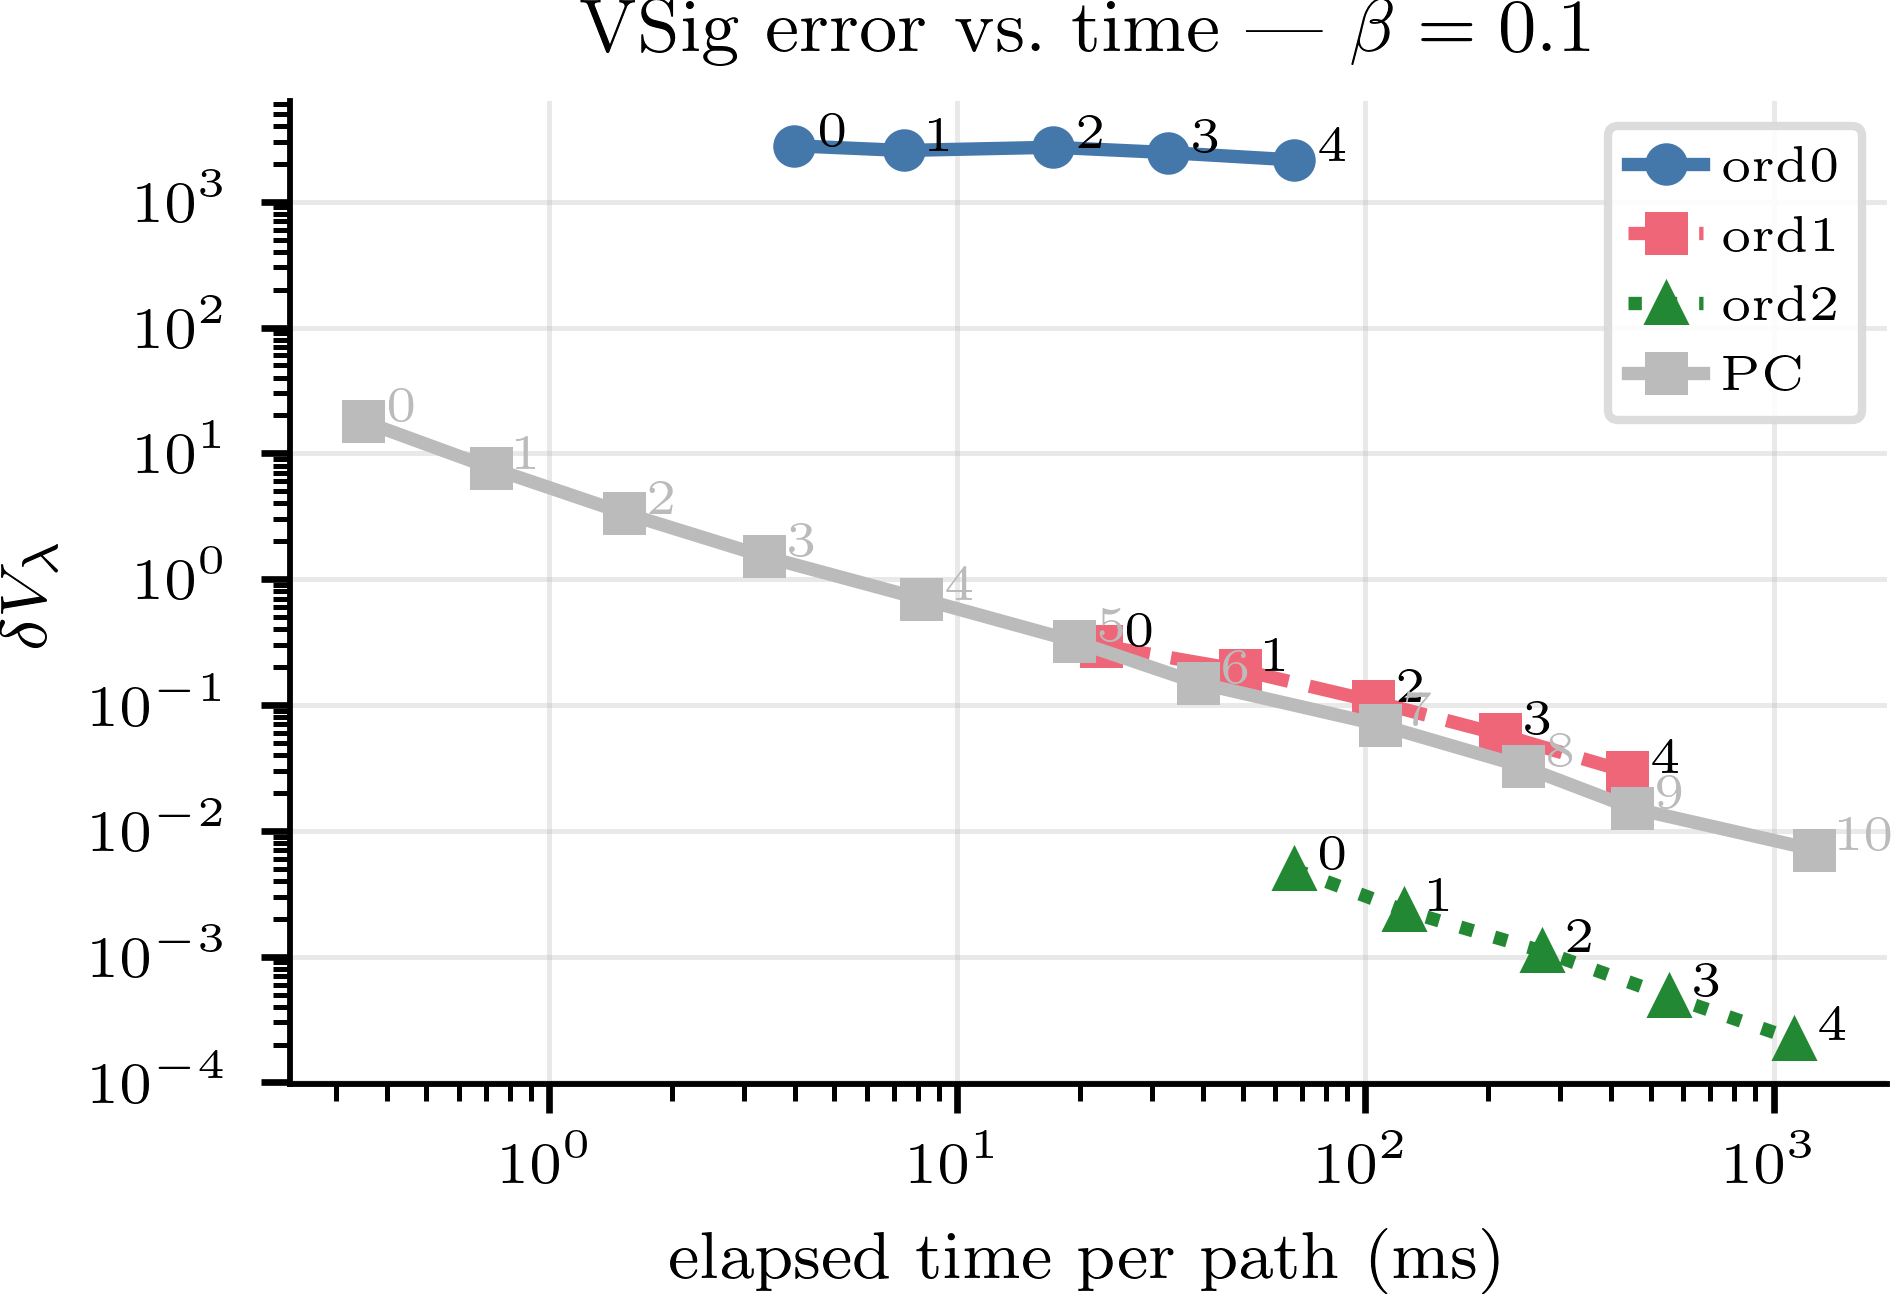

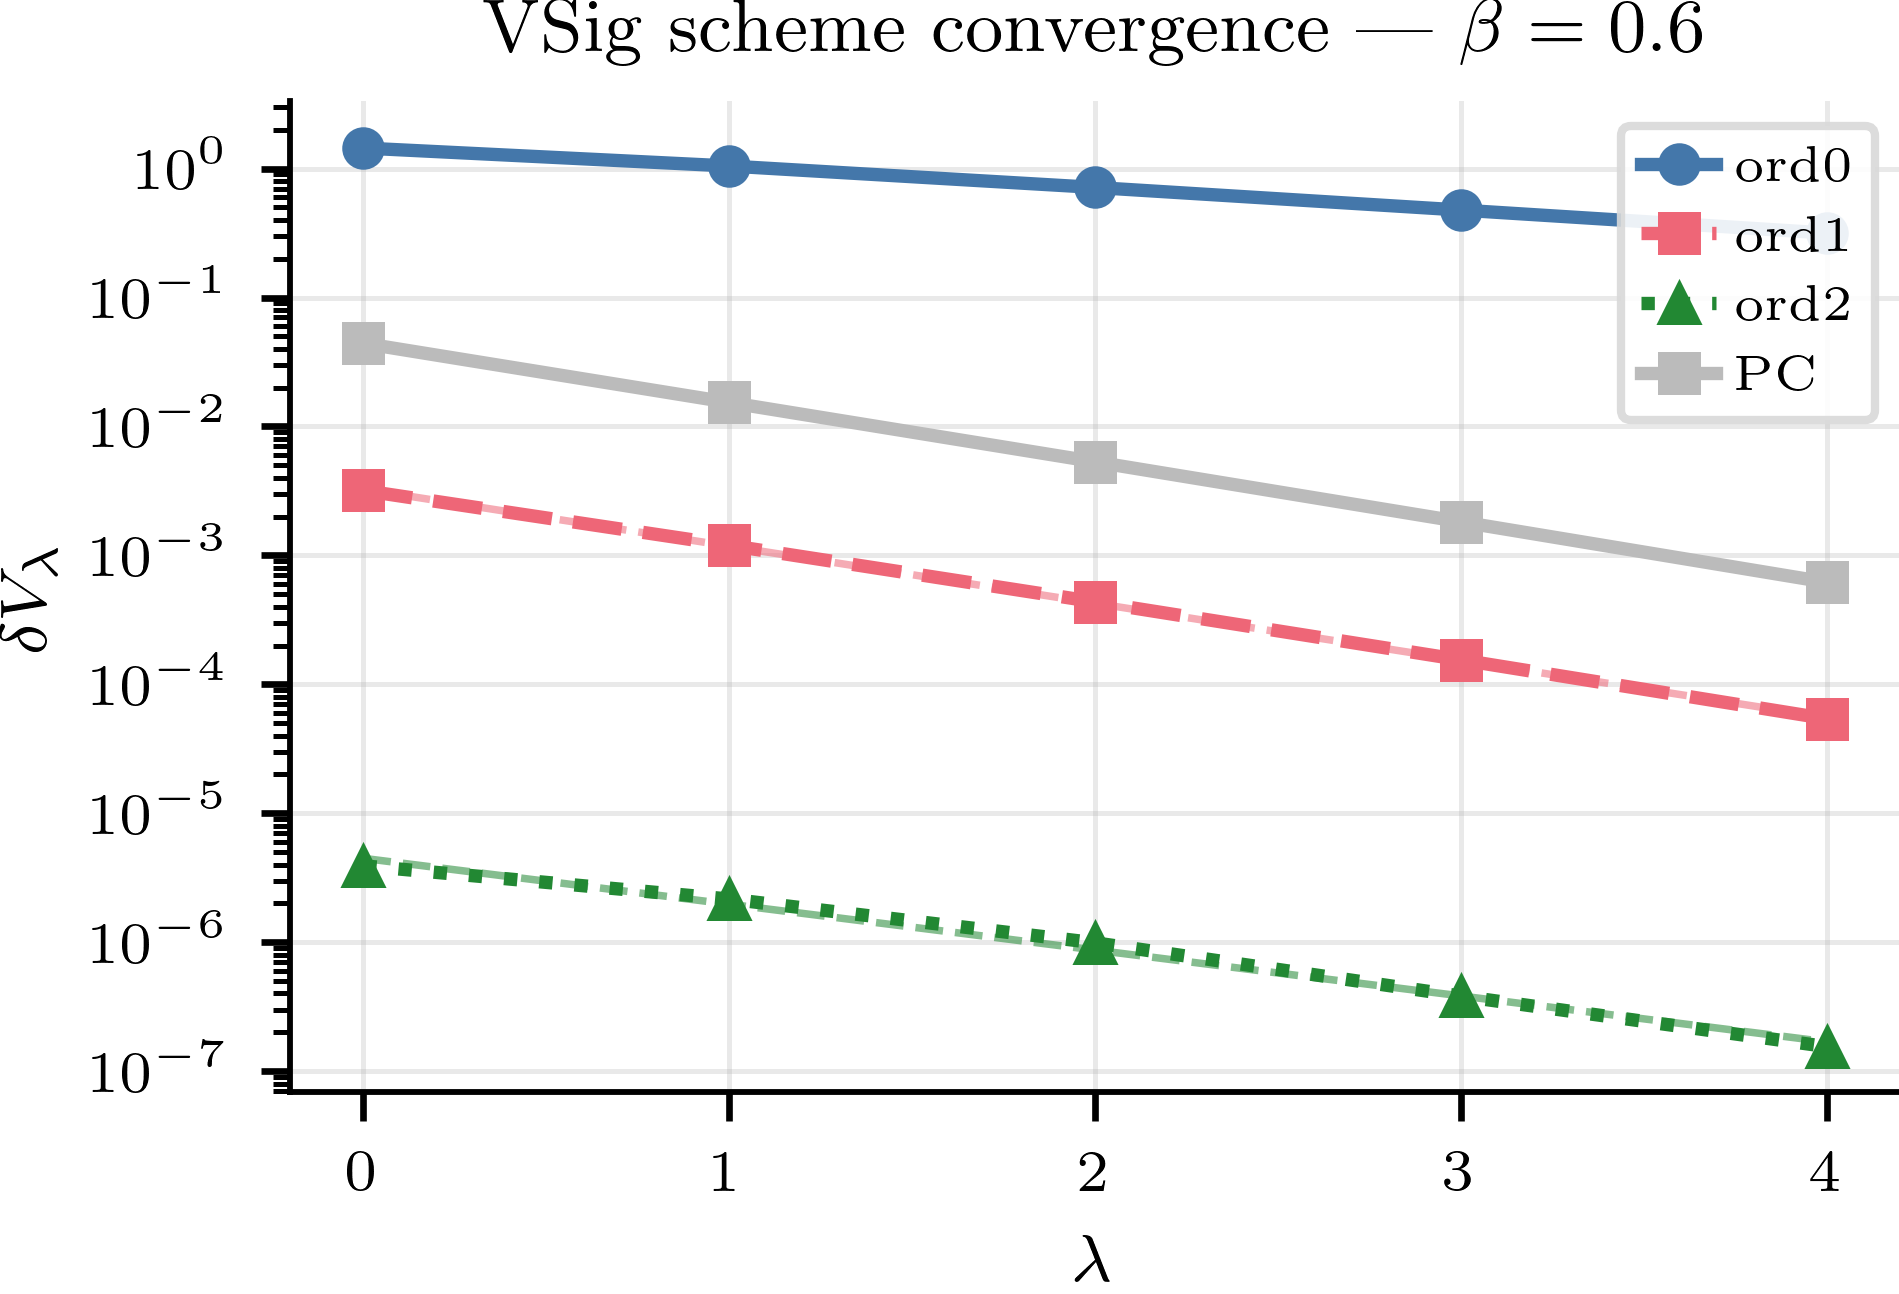

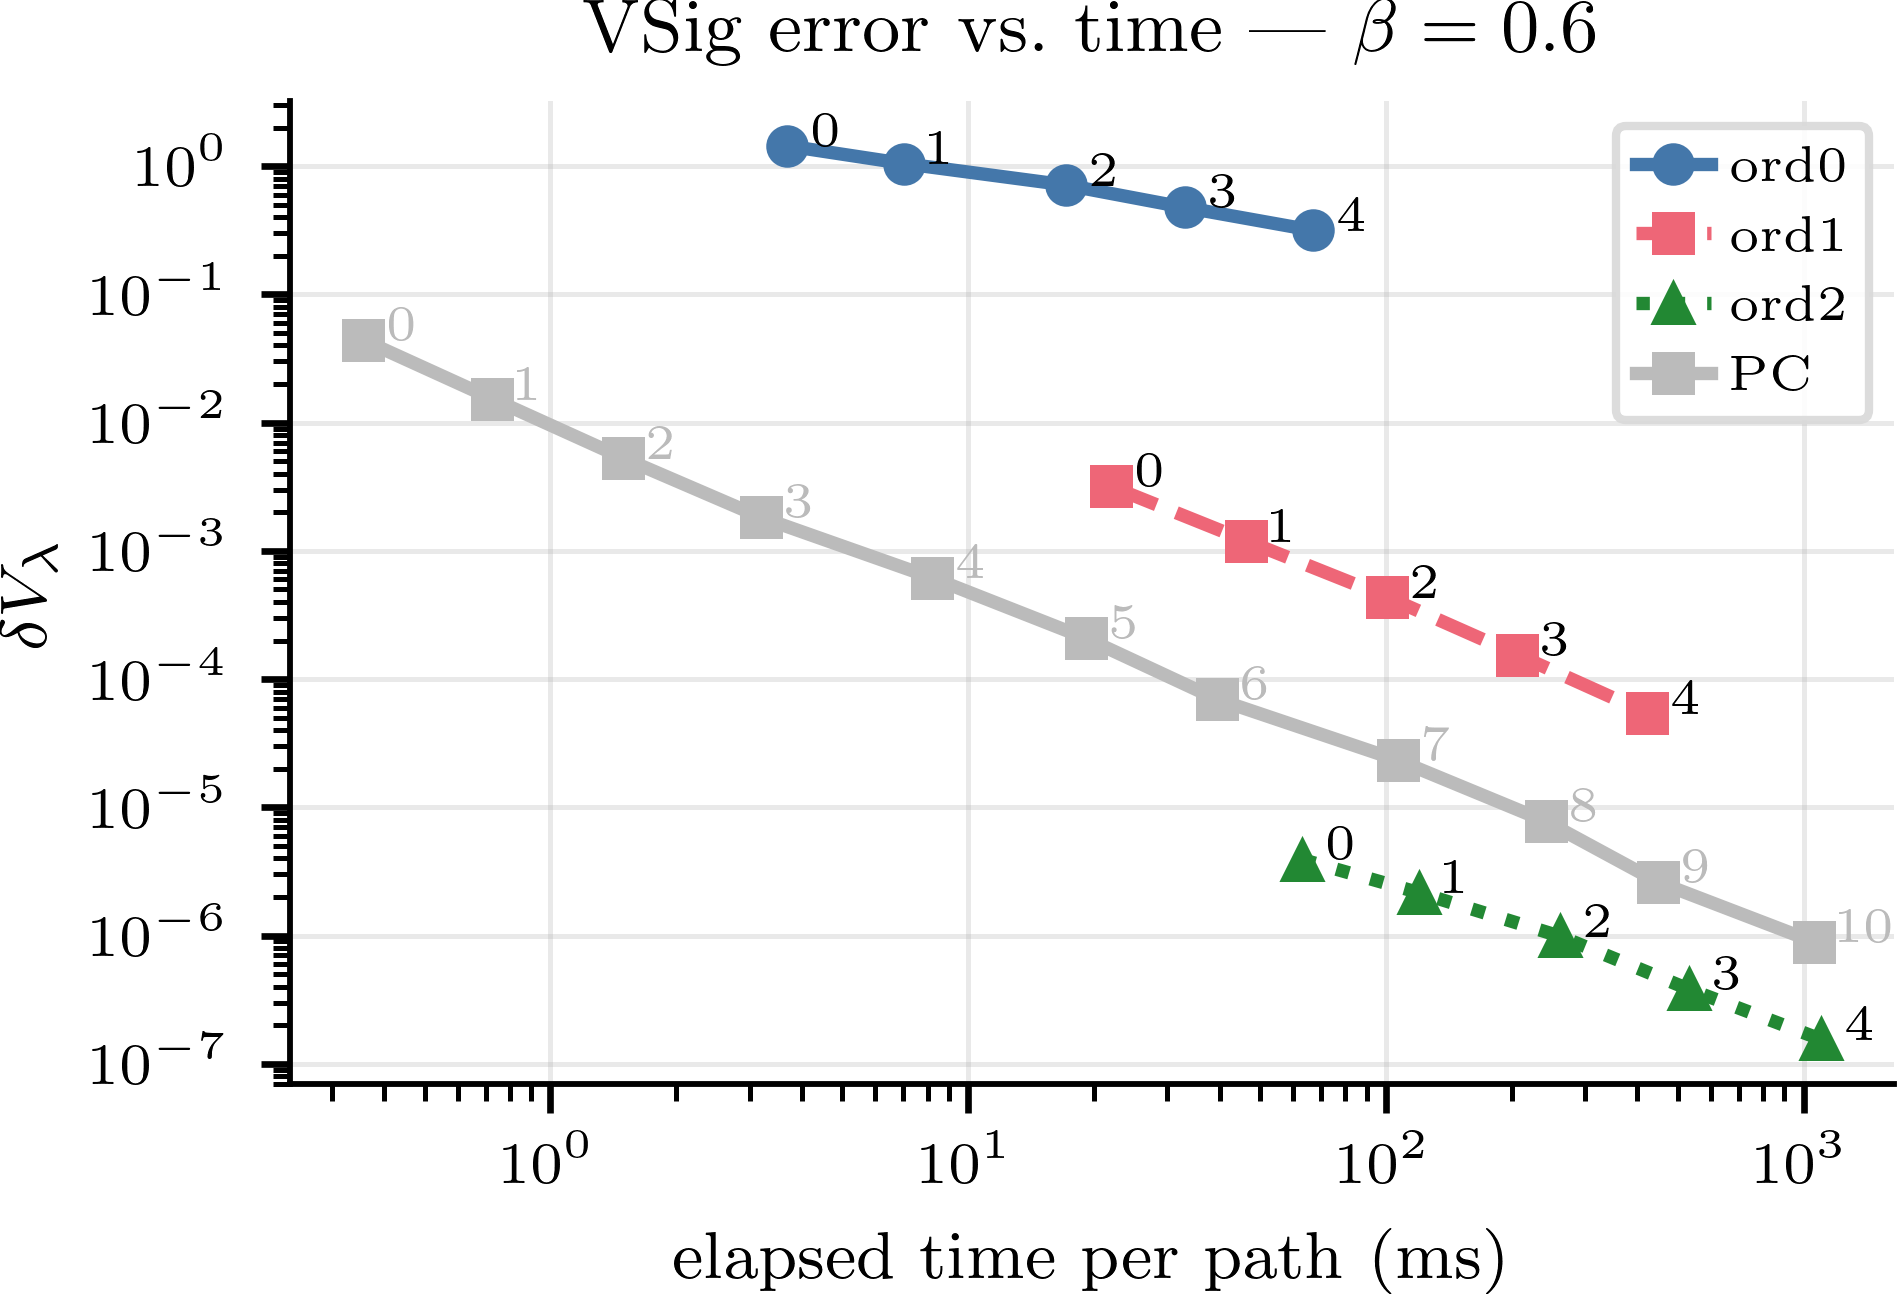

In [12]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path("validation") / OUTPUT_DIR
mode = convergence_mode

display(pd.read_csv(out / f"vsig_conv_{mode}_rates.csv"))

for beta in betas_vsig:
    beta_tag = f"b{beta:.2f}".replace(".", "p")
    for suffix in ["_convergence", "_tradeoff"]:
        img = out / f"vsig_conv_{mode}_{beta_tag}{suffix}.png"
        if img.exists():
            display(Image(filename=str(img)))
        else:
            print(f"  (not found: {img.name})")


## 3. `FSSKConvolutionKernel` adapter correctness

Checks that `vsig_fft` through `ConvolutionKernel.fssk(...)` agrees with the
direct `StateSpaceSignature.vsig` to within tolerance on a fixed path/grid.


In [17]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
adapter_steps     = 65
adapter_batch     = 4
adapter_trunc     = 6
adapter_T         = 1.0
adapter_orders    = [0, 1, 2]
adapter_seed      = 0
adapter_tolerance = 1e-4
adapter_dim       = 3


In [18]:
import subprocess, sys
from pathlib import Path

script = Path("validation/validate_fssk_adapter.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--steps",     str(adapter_steps),
     "--batch",     str(adapter_batch),
     "--trunc",     str(adapter_trunc),
     "--T",         str(adapter_T),
     "--orders",    *[str(o) for o in adapter_orders],
     "--seed",      str(adapter_seed),
     "--tolerance", str(adapter_tolerance),
     "--dim",       str(adapter_dim),
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"validate_fssk_adapter.py failed (exit {result.returncode})")


Generating paths ...
  X.shape: (4, 66, 3)
Computing direct SSS reference ...
  SSS level shapes: [(4, 1), (4, 3), (4, 9), (4, 27), (4, 81), (4, 243), (4, 729)]
  vsig_fft order=0 ... max diff (lvl>0) = 1.041e+00
  vsig_fft order=1 ... max diff (lvl>0) = 7.947e-04
  vsig_fft order=2 ... max diff (lvl>0) = 2.038e-09

Per-level max abs difference (n!-scaled, steps=65):
order             0             1             2
level                                          
0      0.000000e+00  0.000000e+00  0.000000e+00
1      1.665335e-15  1.665335e-15  1.665335e-15
2      4.496343e-03  3.437616e-06  7.580603e-13
3      1.303953e-02  9.957098e-06  5.565248e-11
4      5.428124e-02  4.145436e-05  2.787665e-10
5      1.849444e-01  1.405810e-04  7.309303e-10
6      1.041287e+00  7.946707e-04  2.037600e-09

[FAIL] 7 entries exceed tolerance=0.0001:
 order  level  max_abs_diff
     0      2      0.004496
     0      3      0.013040
     0      4      0.054281
     0      5      0.184944
     0      6  

RuntimeError: validate_fssk_adapter.py failed (exit 1)

## 4. XLA FLOP-count scaling — FFT vs quadratic

Sweeps `(J, N, q)` with `order=2` and `dyadic_order=0` fixed.  For each
configuration three FLOP counts are profiled via abstract (device-free) XLA
compilation:

* **fft_pre** — lag-table precomputation (`precompute_lag_tables`)
* **fft_hot** — FFT hot loop with precomputed tables (`fft_iteration`)
* **quad**    — quadratic hot loop (`quadratic_iteration`)

`fft_total = fft_pre + fft_hot` is derived in the analysis step.

### Expected scaling

| Method | Formula |
|--------|---------|
| quadratic | $J^2 N m^N$ |
| FFT (hot loop) | $J \log_2(J)\, N\, m^N$ |

$m$ = path dimension, $N$ = truncation level.  $q$ contributes only a constant
prefactor (for fixed $q$, $m^N$ dominates the polynomial-in-$N$ multi-index factor),
so both formulas hold for all $q$.

### XLA FLOP-counting behaviour — established in the SSS sweep

* **`fft_iteration`** — uses bare Python `for` loops, which JAX fully unrolls at
  trace time.  XLA sees the complete flat graph and counts every operation correctly.
  No correction needed.  Compile time grows as $O(N^2 B)$ ($B = 5$ for order 2)
  because there are $\sum_{\ell=1}^N \ell = O(N^2)$ unrolled FFT subgraphs.

* **`quadratic_iteration`** — uses `lax.scan` (length $S = J-1$).  XLA
  `cost_analysis()` reports the **body cost once**, not body $\times S$.
  The sweep now stores `quad_flops = body\_flops \times S` and the raw
  `quad_flops_body`.  The analyser applies the same correction retroactively
  to old pickle files that lack `quad_flops_body`.

### Diagnostics

**J-slope** — summary column `J_slope_quad` (OLS slope of $\log(\mathrm{FLOPs})$
on $\log J$ per $(N,q)$ group) should now be $\approx 2$ after the scan correction.
`J_slope_fft` should be $\approx 1$.  Values far from these indicate residual
miscounting or a regime where precomputation dominates.

**q effect** — the by-$q$ scatter plots confirm that $q$ is a vertical shift only
(parallel lines in log-log), not a change in slope.

In [33]:
# ── Parameters (edit here) ──────────────────────────────────────────────────
FLOP_REGIME = "MEDIUM"   # "SMALL" | "MEDIUM" | "LARGE"


In [ ]:
import subprocess, sys
from pathlib import Path

script = Path("validation/sweep_vsig_flop_scaling.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--regime",     FLOP_REGIME,
     "--output-dir", OUTPUT_DIR,
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"sweep_vsig_flop_scaling.py failed (exit {result.returncode})")


Regime         : MEDIUM
Configurations : 800
J range        : 130 – 1023
N range        : 5 – 11
q values       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
d (fixed)      : 3
beta (fixed)   : 0.6
order (fixed)  : 2

[0001/800]  J=453  N=6  q=1
[0002/800]  J=453  N=6  q=2
[0003/800]  J=453  N=6  q=3
[0004/800]  J=453  N=6  q=4
[0005/800]  J=839  N=7  q=1
[0006/800]  J=839  N=7  q=2
[0007/800]  J=839  N=7  q=3
[0008/800]  J=839  N=7  q=4
[0009/800]  J=604  N=7  q=1
[0010/800]  J=604  N=7  q=2
[0011/800]  J=604  N=7  q=3
[0012/800]  J=604  N=7  q=4
[0013/800]  J=205  N=8  q=1
[0014/800]  J=205  N=8  q=2
[0015/800]  J=205  N=8  q=3
[0016/800]  J=205  N=8  q=4
[0017/800]  J=468  N=9  q=1
[0018/800]  J=468  N=9  q=2
[0019/800]  J=468  N=9  q=3
[0020/800]  J=468  N=9  q=4
[0021/800]  J=458  N=6  q=1
[0022/800]  J=458  N=6  q=2
[0023/800]  J=458  N=6  q=3
[0024/800]  J=458  N=6  q=4
[0025/800]  J=294  N=10  q=1
[0026/800]  J=294  N=10  q=2
[0027/800]  J=294  N=10  q=3
[0028/800]  J=

In [31]:
import subprocess, sys
from pathlib import Path

script = Path("validation/analyse_vsig_flop_scaling.py").resolve()
result = subprocess.run(
    [sys.executable, str(script),
     "--regime",     FLOP_REGIME,
     "--output-dir", OUTPUT_DIR,
    ],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"analyse_vsig_flop_scaling.py failed (exit {result.returncode})")


Regime          : MEDIUM
Loaded rows     : 800
Valid rows      : 800
d values (m)    : [np.int64(3)]
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
J values        : [np.int64(130), np.int64(133), np.int64(136), np.int64(138), np.int64(142), np.int64(144), np.int64(150), np.int64(155), np.int64(158), np.int64(163), np.int64(168), np.int64(169), np.int64(175), np.int64(177), np.int64(182), np.int64(183), np.int64(195), np.int64(202), np.int64(203), np.int64(204), np.int64(205), np.int64(207), np.int64(210), np.int64(211), np.int64(212), np.int64(213), np.int64(214), np.int64(216), np.int64(218), np.int64(222), np.int64(223), np.int64(228), np.int64(231), np.int64(232), np.int64(235), np.int64(237), np.int64(241), np.int64(242), np.int64(251), np.int64(266), np.int64(267), np.int64(273), np.int64(277), np.int64(291), np.int64(293), np.int64(296), np.int64(306), np.int64(310), np.int64(311), np.int64(316), np.int64(318), np.int64(321), np.int64(325), np.int64(327),

/Users/paulhager/PycharmProjects/levyMMD/tensordev/notebooks/_validation_util/plot_config.py:205: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(path, **kw)


  Saved: validation_outputs/vsig_flop_scaling_medium_fft.pdf
  Saved: validation_outputs/vsig_flop_scaling_medium_quad.png
  Saved: validation_outputs/vsig_flop_scaling_medium_quad.pdf
Figures saved to validation_outputs/vsig_flop_scaling_medium_{fft,quad}.{png,pdf}


In [ ]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path(OUTPUT_DIR)
tag = FLOP_REGIME.lower()

summary_csv = out / f"vsig_flop_scaling_{tag}_summary.csv"
if summary_csv.exists():
    display(pd.read_csv(summary_csv))

for stem in [f"vsig_flop_scaling_{tag}_fft",
             f"vsig_flop_scaling_{tag}_quad",
             f"vsig_flop_scaling_{tag}_fft_byq",
             f"vsig_flop_scaling_{tag}_quad_byq"]:
    p = out / f"{stem}.png"
    if p.exists():
        display(Image(str(p)))
